<a href="https://colab.research.google.com/github/onishchenkoanastasia5-glitch/Machine_learning/blob/main/%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_3_%D0%9E%D0%BD%D0%B8%D1%89%D0%B5%D0%BD%D0%BA%D0%BE_3_12_Pandas_EDA_2026_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук до лекції 3
## Аналіз даних у pandas та EDA

**Дисципліна:** Машинне навчання  
**Редакція:** 2026  

Мета ноутбука - відпрацювати основні операції pandas на єдиному навчальному наборі даних: завантаження, первинне обстеження, індексацію, очищення, групування, об’єднання, переформатування та базову візуалізацію.

> Матеріал орієнтований на pandas 3.0+. Якщо у Google Colab встановлена інша версія, більшість прикладів все одно виконуватиметься, але dtype текстових стовпців може відрізнятися.

## 0. Підготовка середовища

Спочатку імпортуємо бібліотеки та перевіримо версію pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


## 1. Створення навчального набору даних

Щоб ноутбук був автономним і запускався у Colab без зовнішніх файлів, згенеруємо невеликий набір даних про клієнтів інтернет-магазину. У ньому навмисно є пропуски, дублікати та неакуратні текстові значення.

In [2]:
rng = np.random.default_rng(42)

n = 120
cities = np.array(["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"])
segments = np.array(["basic", "standard", "premium"])

customers = pd.DataFrame({
    "customer_id": np.arange(1001, 1001 + n),
    "age": rng.integers(18, 70, size=n),
    "city": rng.choice(cities, size=n, p=[0.30, 0.20, 0.18, 0.16, 0.16]),
    "segment": rng.choice(segments, size=n, p=[0.45, 0.40, 0.15]),
    "signup_date": pd.Timestamp("2022-01-01") + pd.to_timedelta(
        rng.integers(0, 1600, size=n), unit="D"
    ),
    "orders": rng.poisson(7, size=n),
    "spend": np.round(rng.gamma(shape=2.3, scale=280, size=n), 2),
    "churn": rng.choice([0, 1], size=n, p=[0.78, 0.22]),
})

# Навмисно додаємо проблеми якості даних
customers.loc[[5, 18, 44], "age"] = np.nan
customers.loc[[9, 27, 78, 101], "spend"] = np.nan
customers.loc[12, "city"] = " kyiv "
customers.loc[31, "city"] = "LVIV"
customers.loc[66, "segment"] = None
customers.loc[88, "spend"] = -150.0

# Додаємо два дублікати рядків
customers = pd.concat([customers, customers.iloc[[3, 15]]], ignore_index=True)

customers.to_csv("customers_eda.csv", index=False)
print("Файл створено: customers_eda.csv")
print("Розмір:", customers.shape)
customers.head()

Файл створено: customers_eda.csv
Розмір: (122, 8)


,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


## 2. Завантаження даних та первинна перевірка

Завантажимо CSV так, як це робиться у реальному проєкті.

In [3]:
df = pd.read_csv(
    "customers_eda.csv",
    parse_dates=["signup_date"],
)

df.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


In [4]:
df.shape

(122, 8)

In [5]:
df.columns

Index(['customer_id', 'age', 'city', 'segment', 'signup_date', 'orders',
       'spend', 'churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  122 non-null    int64         
 1   age          119 non-null    float64       
 2   city         122 non-null    object        
 3   segment      121 non-null    object        
 4   signup_date  122 non-null    datetime64[ns]
 5   orders       122 non-null    int64         
 6   spend        118 non-null    float64       
 7   churn        122 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 7.8+ KB


In [7]:
df.describe()

,customer_id,age,signup_date,orders,spend,churn
count,122.000000,119.000000,122,122.000000,118.000000,122.000000
mean,1059.672131,44.512605,2024-04-23 11:00:59.016393472,6.959016,672.393814,0.278689
min,1001.000000,18.000000,2022-01-13 00:00:00,1.000000,-150.000000,0.000000
25%,1029.250000,33.000000,2023-05-01 06:00:00,5.000000,341.800000,0.000000
50%,1059.500000,44.000000,2024-05-06 12:00:00,7.000000,621.640000,0.000000
75%,1089.750000,57.000000,2025-03-27 06:00:00,8.000000,901.750000,1.000000
max,1120.000000,68.000000,2026-05-14 00:00:00,14.000000,2046.770000,1.000000
std,35.100668,14.038606,NaN,2.556462,445.379828,0.450203


### Зверніть увагу
- `shape` показує кількість об'єктів та ознак;
- `info()` допомагає побачити типи й пропуски;
- `describe()` дає базову статистику числових ознак;
- у pandas 3.0 текстові стовпці за замовчуванням можуть мати `str` dtype замість старого `object`.

## 3. Series, DataFrame, loc та iloc

In [8]:
# Один стовпець -> Series
spend = df["spend"]
print(type(spend))

# Кілька стовпців -> DataFrame
small = df[["customer_id", "city", "spend"]]
print(type(small))
small.head()

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,customer_id,city,spend
0,1001,Odesa,347.14
1,1002,Lviv,706.18
2,1003,Odesa,1164.91
3,1004,Dnipro,77.99
4,1005,Odesa,574.75


In [9]:
# loc: вибір за мітками / умовами
high_spend = df.loc[df["spend"] > 1000, ["customer_id", "city", "spend"]]
high_spend.head()

,customer_id,city,spend
2,1003,Odesa,1164.91
6,1007,Odesa,1771.49
15,1016,Kyiv,1190.51
19,1020,Dnipro,1632.17
21,1022,Lviv,1162.84


In [10]:
# iloc: вибір за позиціями
df.iloc[:5, :4]

,customer_id,age,city,segment
0,1001,22.0,Odesa,premium
1,1002,58.0,Lviv,premium
2,1003,52.0,Odesa,standard
3,1004,40.0,Dnipro,basic
4,1005,40.0,Odesa,standard


## 4. Фільтрація даних

In [11]:
mask = (
    df["age"].between(25, 45)
    & df["city"].isin(["Kyiv", "Lviv"])
    & df["spend"].notna()
)

selected = df.loc[mask]
selected.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
8,1009,28.0,Kyiv,standard,2026-03-28,5,409.81,1
10,1011,45.0,Kyiv,premium,2025-08-26,8,134.76,0
16,1017,44.0,Kyiv,standard,2023-02-04,5,425.17,0
21,1022,37.0,Lviv,premium,2024-02-04,8,1162.84,0
30,1031,41.0,Kyiv,standard,2025-03-25,4,851.50,0


In [12]:
# query часто зручний для читабельних числових умов
query_result = df.query("orders >= 8 and spend > 700")
query_result.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
13,1014,57.0,Kyiv,standard,2023-09-09,10,902.89,1
15,1016,58.0,Kyiv,basic,2024-10-20,8,1190.51,1
17,1018,24.0,Odesa,premium,2023-03-03,13,930.86,0


## 5. Пропуски, дублікати та базове очищення

In [13]:
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "share": df.isna().mean(),
}).sort_values("share", ascending=False)

missing

,count,share
spend,4,0.032787
age,3,0.024590
segment,1,0.008197
customer_id,0,0.000000
city,0,0.000000
signup_date,0,0.000000
orders,0,0.000000
churn,0,0.000000


In [14]:
print("Повних дублікатів:", df.duplicated().sum())
print("Дублікатів customer_id:", df.duplicated(subset=["customer_id"]).sum())

Повних дублікатів: 2
Дублікатів customer_id: 2


In [15]:
clean = df.drop_duplicates().copy()

# Негативні витрати трактуємо як помилкове значення
clean.loc[clean["spend"] < 0, "spend"] = np.nan

# Очищення тексту
clean["city"] = clean["city"].str.strip().str.title()
clean["segment"] = clean["segment"].fillna("unknown")

print(clean.shape)
print(clean["city"].value_counts(dropna=False))
print(clean["segment"].value_counts(dropna=False))

(120, 8)
city
Kyiv       38
Lviv       28
Odesa      24
Dnipro     16
Kharkiv    14
Name: count, dtype: int64
segment
basic       58
standard    43
premium     18
unknown      1
Name: count, dtype: int64


### Примітка про ML
У цьому навчальному EDA можна показати заповнення пропусків. Але якщо значення для заповнення (медіана, середнє тощо) використовуватиметься моделлю, його слід оцінювати **лише на train**, бажано всередині `Pipeline`.

In [16]:
# Для дослідницького аналізу створимо окремий стовпець
median_age = clean["age"].median()
clean["age_filled"] = clean["age"].fillna(median_age)

print("Медіана age:", median_age)
clean[["age", "age_filled"]].head(10)

Медіана age: 44.0


,age,age_filled
0,22.0,22.0
1,58.0,58.0
2,52.0,52.0
3,40.0,40.0
4,40.0,40.0
5,NaN,44.0
6,22.0,22.0
7,54.0,54.0
8,28.0,28.0
9,22.0,22.0


## 6. Робота з датами та створення ознак

In [17]:
reference_date = pd.Timestamp("2026-09-07")

clean["signup_year"] = clean["signup_date"].dt.year
clean["signup_month"] = clean["signup_date"].dt.month
clean["tenure_days"] = (reference_date - clean["signup_date"]).dt.days
clean["spend_per_order"] = clean["spend"] / clean["orders"].replace(0, np.nan)

clean[[
    "signup_date", "signup_year", "signup_month",
    "tenure_days", "spend_per_order"
]].head()

,signup_date,signup_year,signup_month,tenure_days,spend_per_order
0,2024-09-13,2024,9,724,86.785000
1,2025-05-31,2025,5,464,78.464444
2,2025-03-28,2025,3,528,105.900909
3,2022-08-04,2022,8,1495,11.141429
4,2025-08-14,2025,8,389,71.843750


## 7. Сортування, groupby та агрегування

In [18]:
top_customers = clean.sort_values("spend", ascending=False).head(10)
top_customers[["customer_id", "city", "segment", "spend"]]

,customer_id,city,segment,spend
34,1035,Lviv,standard,2046.77
67,1068,Kyiv,basic,1972.21
6,1007,Odesa,basic,1771.49
59,1060,Odesa,basic,1653.40
29,1030,Odesa,standard,1651.09
19,1020,Dnipro,basic,1632.17
99,1100,Dnipro,premium,1528.80
84,1085,Lviv,premium,1386.54
57,1058,Dnipro,standard,1358.35
51,1052,Kyiv,basic,1355.64


In [19]:
city_summary = (
    clean.groupby("city", dropna=False)
         .agg(
             customers=("customer_id", "nunique"),
             avg_spend=("spend", "mean"),
             median_spend=("spend", "median"),
             total_spend=("spend", "sum"),
             churn_rate=("churn", "mean"),
         )
         .sort_values("total_spend", ascending=False)
)

city_summary.round(2)

,customers,avg_spend,median_spend,total_spend,churn_rate
city,,,,,
Kyiv,38,678.75,682.37,25792.35,0.26
Lviv,28,705.33,704.74,17633.17,0.21
Odesa,24,655.27,527.90,15726.52,0.38
Dnipro,16,688.37,479.96,10325.49,0.19
Kharkiv,14,672.80,637.44,8746.44,0.36


In [20]:
# transform повертає результат тієї самої довжини, що й початкові дані
city_total = clean.groupby("city")["spend"].transform("sum")
clean["share_in_city"] = clean["spend"] / city_total

clean[["customer_id", "city", "spend", "share_in_city"]].head()

,customer_id,city,spend,share_in_city
0,1001,Odesa,347.14,0.022074
1,1002,Lviv,706.18,0.040048
2,1003,Odesa,1164.91,0.074073
3,1004,Dnipro,77.99,0.007553
4,1005,Odesa,574.75,0.036547


## 8. merge та concat

In [21]:
city_info = pd.DataFrame({
    "city": ["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"],
    "region": ["North", "West", "South", "Center", "East"],
    "priority_market": [1, 1, 0, 0, 1],
})

merged = clean.merge(
    city_info,
    on="city",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print(merged["_merge"].value_counts())
merged.head()

_merge
both          120
left_only       0
right_only      0
Name: count, dtype: int64


,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city,region,priority_market,_merge
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074,South,0,both
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048,West,1,both
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073,South,0,both
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553,Center,0,both
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547,South,0,both


In [22]:
first_half = clean.iloc[:60]
second_half = clean.iloc[60:]
restored = pd.concat([first_half, second_half], ignore_index=True)

print(clean.shape, restored.shape)

(120, 14) (120, 14)


## 9. pivot_table, crosstab та melt

In [23]:
pivot = pd.pivot_table(
    clean,
    values="spend",
    index="city",
    columns="segment",
    aggfunc="mean",
    fill_value=0,
)

pivot.round(2)

segment,basic,premium,standard,unknown
city,,,,
Dnipro,638.73,979.02,583.47,0.00
Kharkiv,602.54,762.48,750.92,0.00
Kyiv,715.81,598.02,657.28,0.00
Lviv,706.03,700.24,696.94,777.76
Odesa,730.47,639.00,605.72,0.00


In [24]:
churn_table = pd.crosstab(
    clean["segment"],
    clean["churn"],
    normalize="index",
)

churn_table.round(3)

churn,0,1
segment,,
basic,0.759,0.241
premium,0.778,0.222
standard,0.674,0.326
unknown,0.000,1.000


In [25]:
wide = city_summary.reset_index()[["city", "avg_spend", "churn_rate"]]
long = wide.melt(
    id_vars="city",
    var_name="metric",
    value_name="value",
)
long.head(10)

,city,metric,value
0,Kyiv,avg_spend,678.746053
1,Lviv,avg_spend,705.326800
2,Odesa,avg_spend,655.271667
3,Dnipro,avg_spend,688.366000
4,Kharkiv,avg_spend,672.803077
5,Kyiv,churn_rate,0.263158
6,Lviv,churn_rate,0.214286
7,Odesa,churn_rate,0.375000
8,Dnipro,churn_rate,0.187500
9,Kharkiv,churn_rate,0.357143


## 10. Кореляція та пошук потенційних викидів

In [26]:
numeric_cols = ["age", "orders", "spend", "churn", "tenure_days"]
correlation = clean[numeric_cols].corr(method="pearson")
correlation.round(2)

,age,orders,spend,churn,tenure_days
age,1.00,-0.05,-0.08,0.08,0.01
orders,-0.05,1.00,-0.08,-0.05,-0.07
spend,-0.08,-0.08,1.00,-0.01,-0.02
churn,0.08,-0.05,-0.01,1.00,-0.15
tenure_days,0.01,-0.07,-0.02,-0.15,1.00


In [27]:
q1 = clean["spend"].quantile(0.25)
q3 = clean["spend"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = clean.loc[~clean["spend"].between(lower, upper) & clean["spend"].notna()]
print("Межі IQR:", round(lower, 2), round(upper, 2))
print("Кількість потенційних викидів:", len(outliers))
outliers[["customer_id", "city", "spend"]].head()

Межі IQR: -480.7 1729.4
Кількість потенційних викидів: 3


,customer_id,city,spend
6,1007,Odesa,1771.49
34,1035,Lviv,2046.77
67,1068,Kyiv,1972.21


## 11. Базова візуалізація

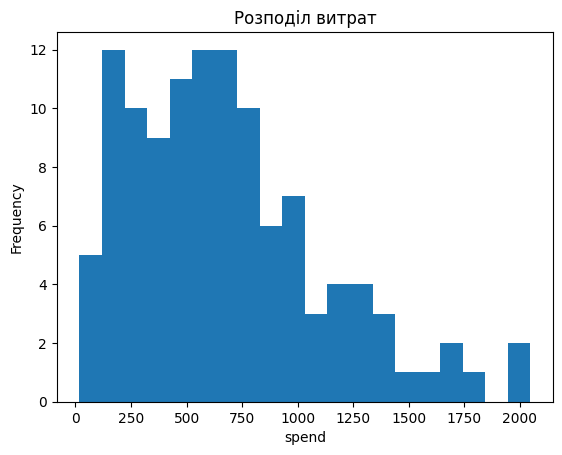

In [28]:
clean["spend"].plot(kind="hist", bins=20, title="Розподіл витрат")
plt.xlabel("spend")
plt.show()

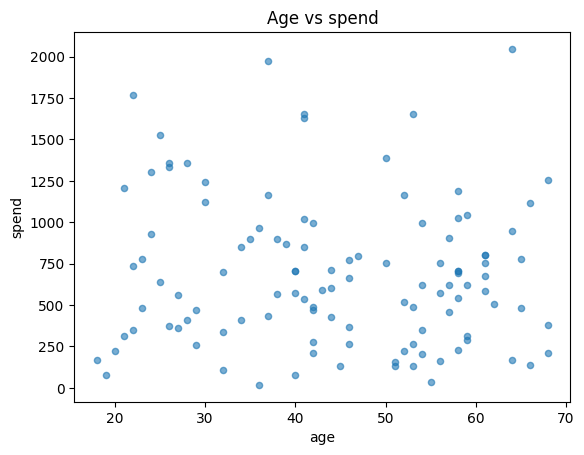

In [29]:
clean.plot.scatter(x="age", y="spend", alpha=0.6, title="Age vs spend")
plt.show()

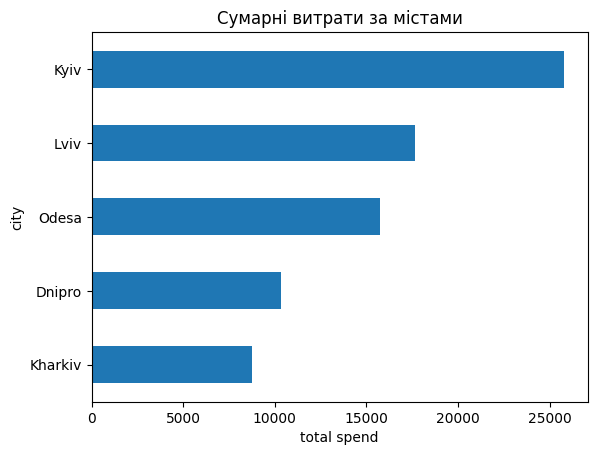

In [30]:
city_summary["total_spend"].sort_values().plot(
    kind="barh",
    title="Сумарні витрати за містами",
)
plt.xlabel("total spend")
plt.show()

## 12. EDA і data leakage

Нижче показано лише **правильну послідовність**: спочатку train/test split, потім статистики preprocessing оцінюються на train.

In [31]:
clean

,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1116,47.0,Kyiv,premium,2025-07-02,5,795.16,0,47.0,2025,7,432,159.032000,0.030829
116,1117,19.0,Lviv,premium,2024-04-08,11,79.78,1,19.0,2024,4,882,7.252727,0.004524
117,1118,25.0,Kharkiv,standard,2024-02-27,6,637.44,0,25.0,2024,2,923,106.240000,0.072880
118,1119,30.0,Kharkiv,standard,2023-01-13,7,1243.22,0,30.0,2023,1,1333,177.602857,0.142140


In [32]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    clean,
    test_size=0.2,
    random_state=42,
    stratify=clean["churn"],
)

train_median = train_df["age"].median()
train_age = train_df["age"].fillna(train_median)
test_age = test_df["age"].fillna(train_median)

print("train:", train_df.shape)
print("test:", test_df.shape)
print("Медіана, оцінена лише на train:", train_median)

train: (96, 14)
test: (24, 14)
Медіана, оцінена лише на train: 44.0


# Завдання для студентів

Виконайте завдання нижче самостійно. Після кожного завдання додайте короткий висновок у Markdown-комірці: **що саме було виявлено і чому це важливо**.

## Завдання 1. Первинний аудит даних
1. Визначте розмір `df`.
2. Виведіть типи всіх стовпців.
3. Порахуйте кількість унікальних значень у кожному стовпці.
4. Визначте частку пропусків.
5. Назвіть щонайменше три потенційні проблеми якості даних.

In [34]:

print("1) Розмір df (рядки, стовпці):", df.shape)

print("\n2) Типи стовпців:")
print(df.dtypes)

print("\n3) Кількість унікальних значень:")
print(df.nunique())

print("\n4) Пропуски:")
audit = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "share_missing": df.isna().mean().round(4),
    "n_unique": df.nunique(),
    "dtype": df.dtypes.astype(str),
}).sort_values("share_missing", ascending=False)
display(audit)

print("\n5) Додаткові перевірки якості:")
print("Повних дублікатів рядків:", df.duplicated().sum())
print("Дублікатів customer_id:", df.duplicated(subset=["customer_id"]).sum())
print("Від'ємних значень spend:", (df["spend"] < 0).sum())
print("\nУнікальні написання city:")
print(df["city"].value_counts(dropna=False))

1) Розмір df (рядки, стовпці): (122, 8)

2) Типи стовпців:
customer_id             int64
age                   float64
city                   object
segment                object
signup_date    datetime64[ns]
orders                  int64
spend                 float64
churn                   int64
dtype: object

3) Кількість унікальних значень:
customer_id    120
age             45
city             7
segment          3
signup_date    117
orders          14
spend          116
churn            2
dtype: int64

4) Пропуски:


,n_missing,share_missing,n_unique,dtype
spend,4,0.0328,116,float64
age,3,0.0246,45,float64
segment,1,0.0082,3,object
customer_id,0,0.0000,120,int64
city,0,0.0000,7,object
signup_date,0,0.0000,117,datetime64[ns]
orders,0,0.0000,14,int64
churn,0,0.0000,2,int64



5) Додаткові перевірки якості:
Повних дублікатів рядків: 2
Дублікатів customer_id: 2
Від'ємних значень spend: 1

Унікальні написання city:
city
Kyiv       38
Lviv       27
Odesa      24
Dnipro     17
Kharkiv    14
 kyiv       1
LVIV        1
Name: count, dtype: int64


## Завдання 2. Фільтрація
Створіть DataFrame `task2`, який містить клієнтів:
- віком від 30 до 50 років;
- із сегменту `premium` або `standard`;
- з витратами понад 600;
- лише зі стовпцями `customer_id`, `age`, `city`, `segment`, `spend`.

Відсортуйте результат за `spend` за спаданням.

In [35]:
mask2 = (
    df["age"].between(30, 50)          # включно з межами
    & df["segment"].isin(["premium", "standard"])
    & (df["spend"] > 600)
)

task2 = (
    df.loc[mask2, ["customer_id", "age", "city", "segment", "spend"]]
      .sort_values("spend", ascending=False)
      .reset_index(drop=True)
)

print("Відібрано рядків:", len(task2))
print("Розподіл за сегментами:")
print(task2["segment"].value_counts())
task2


Відібрано рядків: 16
Розподіл за сегментами:
segment
standard    9
premium     7
Name: count, dtype: int64


,customer_id,age,city,segment,spend
0,1030,41.0,Odesa,standard,1651.09
1,1085,50.0,Lviv,premium,1386.54
2,1119,30.0,Kharkiv,standard,1243.22
3,1022,37.0,Lviv,premium,1162.84
4,1076,42.0,Kyiv,standard,997.35
5,1044,36.0,Kharkiv,premium,963.23
6,1077,35.0,Kharkiv,standard,898.33
7,1065,39.0,Kyiv,standard,870.96
8,1031,41.0,Kyiv,standard,851.50
9,1066,34.0,Lviv,premium,848.28


## Завдання 3. Очищення
На копії `df` виконайте:
1. видалення повних дублікатів;
2. очищення пробілів і регістру в `city`;
3. заміну від’ємних `spend` на пропуск;
4. підрахунок кількості пропусків після очищення;
5. поясніть, які пропуски ви б видаляли, а які — імпутували.

In [36]:
task3 = df.copy()

before = task3.shape[0]
task3 = task3.drop_duplicates().copy()
print("Видалено повних дублікатів:", before - task3.shape[0])

task3["city"] = task3["city"].str.strip().str.title()
print("\nМіста після нормалізації:")
print(task3["city"].value_counts(dropna=False))

n_neg = (task3["spend"] < 0).sum()
task3.loc[task3["spend"] < 0, "spend"] = np.nan
print("\nЗамінено від'ємних spend на NaN:", n_neg)

print("\nПропуски після очищення:")
print(pd.DataFrame({
    "n_missing": task3.isna().sum(),
    "share_missing": task3.isna().mean().round(4),
}))

print("\nРозмір після очищення:", task3.shape)


Видалено повних дублікатів: 2

Міста після нормалізації:
city
Kyiv       38
Lviv       28
Odesa      24
Dnipro     16
Kharkiv    14
Name: count, dtype: int64

Замінено від'ємних spend на NaN: 1

Пропуски після очищення:
             n_missing  share_missing
customer_id          0         0.0000
age                  3         0.0250
city                 0         0.0000
segment              1         0.0083
signup_date          0         0.0000
orders               0         0.0000
spend                5         0.0417
churn                0         0.0000

Розмір після очищення: (120, 8)


## Завдання 4. Групова аналітика
Для кожного `segment` обчисліть:
- кількість клієнтів;
- середню кількість замовлень;
- медіанні витрати;
- сумарні витрати;
- churn rate.

Відсортуйте сегменти за churn rate від найбільшого до найменшого.

In [37]:
segment_summary = (
    task3.groupby("segment", dropna=False)
         .agg(
             n_customers=("customer_id", "nunique"),
             avg_orders=("orders", "mean"),
             median_spend=("spend", "median"),
             total_spend=("spend", "sum"),
             churn_rate=("churn", "mean"),
         )
         .sort_values("churn_rate", ascending=False)
)

segment_summary.round(3)


,n_customers,avg_orders,median_spend,total_spend,churn_rate
segment,,,,,
NaN,1,6.000,777.760,777.76,1.000
standard,43,7.000,503.860,27178.88,0.326
basic,58,6.793,668.135,37335.78,0.241
premium,18,7.389,738.405,12931.55,0.222


## Завдання 5. Ознаки на основі дат
Створіть:
- `signup_year`;
- `signup_quarter`;
- `tenure_days` станом на 07.09.2026.

Після цього визначте, у якому році зареєструвалося найбільше клієнтів.

In [38]:
reference_date_task = pd.Timestamp("2026-09-07")

task5 = task3.copy()
task5["signup_year"] = task5["signup_date"].dt.year
task5["signup_quarter"] = task5["signup_date"].dt.quarter
task5["tenure_days"] = (reference_date_task - task5["signup_date"]).dt.days

display(task5[["signup_date", "signup_year", "signup_quarter", "tenure_days"]].head())

year_counts = task5["signup_year"].value_counts().sort_index()
print("Реєстрації за роками:")
print(year_counts)
print("\nНайбільше реєстрацій у році:", year_counts.idxmax(), "-", year_counts.max(), "клієнтів")
print("Діапазон tenure_days:", task5["tenure_days"].min(), "-", task5["tenure_days"].max())

,signup_date,signup_year,signup_quarter,tenure_days
0,2024-09-13,2024,3,724
1,2025-05-31,2025,2,464
2,2025-03-28,2025,1,528
3,2022-08-04,2022,3,1495
4,2025-08-14,2025,3,389


Реєстрації за роками:
signup_year
2022    22
2023    21
2024    37
2025    27
2026    13
Name: count, dtype: int64

Найбільше реєстрацій у році: 2024 - 37 клієнтів
Діапазон tenure_days: 116 - 1698


## Завдання 6. Об’єднання таблиць
Створіть окрему таблицю `segment_info` з полями:
- `segment`;
- `discount_rate`;
- `support_level`.

Об’єднайте її з очищеним набором через `merge`. Обов’язково використайте `validate` і поясніть, який тип зв’язку очікується.

In [39]:
segment_info = pd.DataFrame({
    "segment": ["basic", "standard", "premium", "unknown"],
    "discount_rate": [0.00, 0.05, 0.12, 0.00],
    "support_level": ["email", "email+chat", "personal manager", "email"],
})
display(segment_info)

task6_left = task5.copy()
task6_left["segment"] = task6_left["segment"].fillna("unknown")

task6 = task6_left.merge(
    segment_info,
    on="segment",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print("Результат зіставлення:")
print(task6["_merge"].value_counts())
print("\nРозмір до merge:", task6_left.shape, "-> після merge:", task6.shape)

task6[["customer_id", "segment", "discount_rate", "support_level", "_merge"]].head(10)


,segment,discount_rate,support_level
0,basic,0.00,email
1,standard,0.05,email+chat
2,premium,0.12,personal manager
3,unknown,0.00,email


Результат зіставлення:
_merge
both          120
left_only       0
right_only      0
Name: count, dtype: int64

Розмір до merge: (120, 11) -> після merge: (120, 14)


,customer_id,segment,discount_rate,support_level,_merge
0,1001,premium,0.12,personal manager,both
1,1002,premium,0.12,personal manager,both
2,1003,standard,0.05,email+chat,both
3,1004,basic,0.00,email,both
4,1005,standard,0.05,email+chat,both
5,1006,standard,0.05,email+chat,both
6,1007,basic,0.00,email,both
7,1008,basic,0.00,email,both
8,1009,standard,0.05,email+chat,both
9,1010,basic,0.00,email,both


## Завдання 7. Pivot table
Побудуйте `pivot_table`, де:
- рядки — `city`;
- стовпці — `segment`;
- значення — медіана `spend`.

Визначте комбінацію місто–сегмент із найбільшою медіаною витрат.

In [40]:
pivot_median = pd.pivot_table(
    task6,
    values="spend",
    index="city",
    columns="segment",
    aggfunc="median",
)
display(pivot_median.round(2))

counts = pd.pivot_table(task6, values="spend", index="city", columns="segment", aggfunc="size")
print("Кількість клієнтів у комірках:")
display(counts)

best = pivot_median.stack()
print("Найбільша медіана витрат:",
      best.idxmax(), "->", round(best.max(), 2))


segment,basic,premium,standard,unknown
city,,,,
Dnipro,703.23,1254.48,456.84,NaN
Kharkiv,533.90,762.48,767.88,NaN
Kyiv,663.68,701.06,727.90,NaN
Lviv,679.78,777.23,425.10,777.76
Odesa,672.59,639.00,489.18,NaN


Кількість клієнтів у комірках:


segment,basic,premium,standard,unknown
city,,,,
Dnipro,8.0,3.0,5.0,NaN
Kharkiv,8.0,2.0,4.0,NaN
Kyiv,19.0,5.0,14.0,NaN
Lviv,14.0,6.0,7.0,1.0
Odesa,9.0,2.0,13.0,NaN


Найбільша медіана витрат: ('Dnipro', 'premium') -> 1254.48


## Завдання 8. Візуалізація
Побудуйте щонайменше три різні графіки:
1. розподіл `age`;
2. boxplot `spend` за сегментами;
3. churn rate за містами.

Для кожного графіка напишіть 1–2 речення інтерпретації.

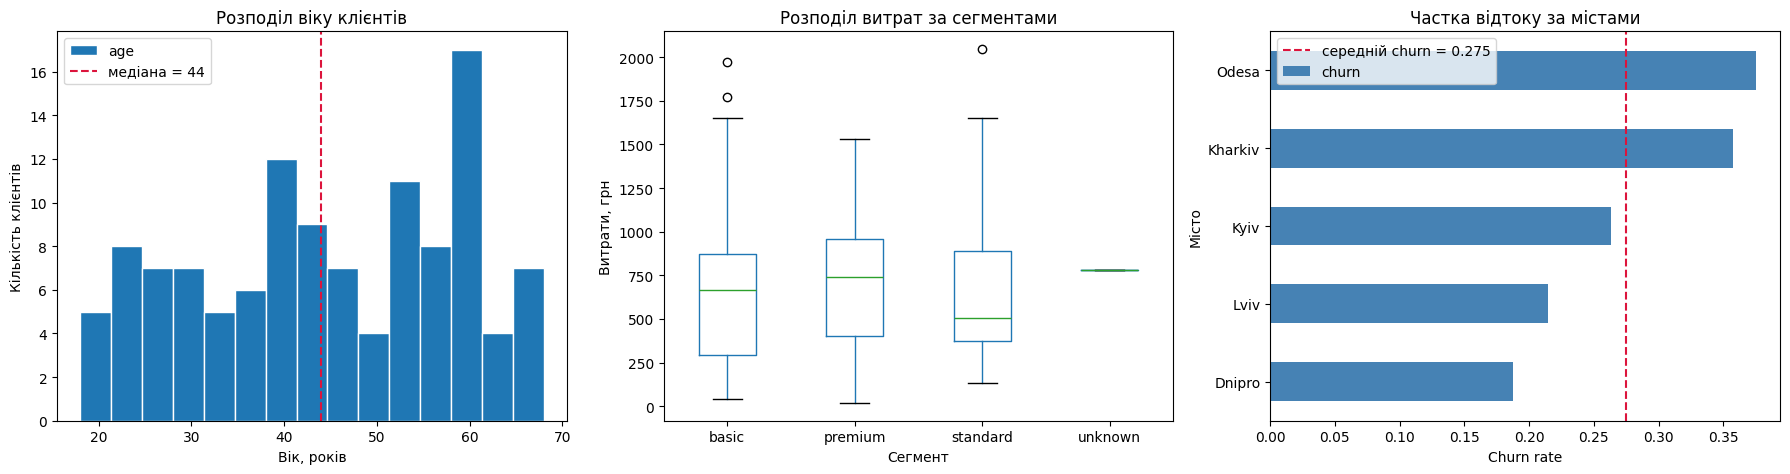

Churn rate за містами:
city
Odesa      0.375
Kharkiv    0.357
Kyiv       0.263
Lviv       0.214
Dnipro     0.188
Name: churn, dtype: float64


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1.
task6["age"].plot(kind="hist", bins=15, edgecolor="white", ax=axes[0])
axes[0].axvline(task6["age"].median(), color="crimson", linestyle="--",
                label=f"медіана = {task6['age'].median():.0f}")
axes[0].set_title("Розподіл віку клієнтів")
axes[0].set_xlabel("Вік, років")
axes[0].set_ylabel("Кількість клієнтів")
axes[0].legend()

# 2.
task6.boxplot(column="spend", by="segment", ax=axes[1], grid=False)
axes[1].set_title("Розподіл витрат за сегментами")
axes[1].set_xlabel("Сегмент")
axes[1].set_ylabel("Витрати, грн")

# 3.
churn_by_city = task6.groupby("city")["churn"].mean().sort_values()
churn_by_city.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].axvline(task6["churn"].mean(), color="crimson", linestyle="--",
                label=f"середній churn = {task6['churn'].mean():.3f}")
axes[2].set_title("Частка відтоку за містами")
axes[2].set_xlabel("Churn rate")
axes[2].set_ylabel("Місто")
axes[2].legend()

plt.suptitle("")
plt.tight_layout()
plt.show()

print("Churn rate за містами:")
print(churn_by_city.round(3).sort_values(ascending=False))


## Завдання 9. Викиди
За правилом IQR знайдіть потенційні викиди `spend`.

Далі порівняйте середнє та медіану `spend` до і після **тимчасового** виключення цих рядків. Не видаляйте викиди з фінального DataFrame автоматично. Поясніть, чому.

In [42]:
q1 = task6["spend"].quantile(0.25)
q3 = task6["spend"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
print(f"Межі: [{lower:.2f}, {upper:.2f}]")

outliers = task6.loc[~task6["spend"].between(lower, upper) & task6["spend"].notna()]
print("Кількість потенційних викидів:", len(outliers))
display(outliers[["customer_id", "city", "segment", "orders", "spend"]])

without_outliers = task6.loc[task6["spend"].between(lower, upper), "spend"]

comparison = pd.DataFrame({
    "З викидами": [task6["spend"].mean(), task6["spend"].median(),
                   task6["spend"].std(), task6["spend"].count()],
    "Без викидів": [without_outliers.mean(), without_outliers.median(),
                    without_outliers.std(), without_outliers.count()],
}, index=["Середнє", "Медіана", "Ст. відхилення", "К-сть значень"])

display(comparison.round(2))

print("Розмір фінального DataFrame не змінився:", task6.shape)

Q1 = 348.08, Q3 = 900.61, IQR = 552.53
Межі: [-480.70, 1729.40]
Кількість потенційних викидів: 3


,customer_id,city,segment,orders,spend
6,1007,Odesa,basic,3,1771.49
34,1035,Lviv,standard,5,2046.77
67,1068,Kyiv,basic,9,1972.21


,З викидами,Без викидів
Середнє,680.21,646.73
Медіана,623.25,612.16
Ст. відхилення,438.33,391.92
К-сть значень,115.00,112.00


Розмір фінального DataFrame не змінився: (120, 14)


## Завдання 10. Підсумковий EDA
Підготуйте короткий аналітичний висновок за набором даних. Він має містити:
- розмір і структуру даних;
- проблеми якості;
- 3–5 ключових статистичних спостережень;
- щонайменше 2 візуальні спостереження;
- потенційні ознаки для ML-моделі прогнозування `churn`;
- ризики data leakage;
- план preprocessing перед моделюванням.

In [43]:
print("=" * 60)
print("РОЗМІР І СТРУКТУРА")
print("=" * 60)
print("Початковий df:", df.shape, "-> після очищення:", task6.shape[0], "рядків")
print("Числові ознаки:", list(task6.select_dtypes("number").columns))

print("\n" + "=" * 60)
print("ЦІЛЬОВА ЗМІННА CHURN")
print("=" * 60)
print(task6["churn"].value_counts(normalize=True).round(3))
print("Дисбаланс класів:", f"{task6['churn'].mean():.1%} позитивного класу")

print("\n" + "=" * 60)
print("КОРЕЛЯЦІЯ З CHURN")
print("=" * 60)
numeric_for_corr = ["age", "orders", "spend", "tenure_days", "churn"]
print(task6[numeric_for_corr].corr()["churn"].round(3).sort_values())

print("\n" + "=" * 60)
print("CHURN У РОЗРІЗІ КАТЕГОРІЙ")
print("=" * 60)
print("За сегментами:")
print(task6.groupby("segment")["churn"].agg(["mean", "size"]).round(3))
print("\nЗа містами:")
print(task6.groupby("city")["churn"].agg(["mean", "size"]).round(3))


РОЗМІР І СТРУКТУРА
Початковий df: (122, 8) -> після очищення: 120 рядків
Числові ознаки: ['customer_id', 'age', 'orders', 'spend', 'churn', 'signup_year', 'signup_quarter', 'tenure_days', 'discount_rate']

ЦІЛЬОВА ЗМІННА CHURN
churn
0    0.725
1    0.275
Name: proportion, dtype: float64
Дисбаланс класів: 27.5% позитивного класу

КОРЕЛЯЦІЯ З CHURN
tenure_days   -0.147
orders        -0.053
spend         -0.007
age            0.085
churn          1.000
Name: churn, dtype: float64

CHURN У РОЗРІЗІ КАТЕГОРІЙ
За сегментами:
           mean  size
segment              
basic     0.241    58
premium   0.222    18
standard  0.326    43
unknown   1.000     1

За містами:
          mean  size
city                
Dnipro   0.188    16
Kharkiv  0.357    14
Kyiv     0.263    38
Lviv     0.214    28
Odesa    0.375    24


## Критерії самоперевірки

Робота виконана якісно, якщо:
- код запускається послідовно без помилок;
- вихідний DataFrame не змінюється випадково через неявні присвоєння;
- для вибірки за умовами використано `loc`;
- пропуски й дублікати не обробляються без пояснення;
- `merge` перевіряє очікувану кардинальність через `validate`;
- графіки мають назви та зрозумілі осі;
- висновки містять інтерпретацію, а не лише перелік чисел;
- при переході до ML враховано ризик витоку даних.